# **Doggo Breed Prediction**

In [ ]:
#!pip install opencv-python opencv-python-headless

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   - -------------------------------------- 1.6/39.5 MB 10.5 MB/s eta 0:00:04
   --- ------------------------------------ 3.4/39.5 MB 11.2 MB/s eta 0:00:04
   ------ --------------------------------- 6.8/39.5 MB 11.6 MB/s eta 0:00:03
   --------- ------------------------------ 9.2/39.5 MB 11.6 MB/s eta 0:00:03
   ----------- ---------------------------- 11.5/39.5 MB 11.6 MB/s eta 0:00:03
   -------------- ------------------------- 14.2/39.5 MB 11.7 MB/s eta 0:00:03
   ---------------- ----------------------- 16.5/39.5 MB 11.7 MB/s eta 0:00:02
   ------------------- -------------------- 18.9/39.5 MB 11.6 MB/s eta 0:00:02
   --------------------- ------------------ 21.2/39.5 MB 11.6 MB/s eta 0:00:02
   ----------------------- ---------------- 23.6/39.5 MB 11.6 MB/s eta 0:00:02
   -------------------------- ------------- 25.7/39.5 MB 11.5 MB/s eta 0:00:02
   ---------------------------- ----------- 28.0/39.5 MB 11.5 MB/

In [1]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from keras.utils import load_img, img_to_array
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam

In [2]:
od.download("https://www.kaggle.com/datasets/catherinehorng/dogbreedidfromcomp")

Skipping, found downloaded files in ".\dogbreedidfromcomp" (use force=True to force download)


In [3]:
labels_all = pd.read_csv("dogbreedidfromcomp\labels.csv")

In [4]:
labels_all.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [5]:
print(labels_all.shape)

(10222, 2)


In [6]:
labels_all["breed"].unique()

array(['boston_bull', 'dingo', 'pekinese', 'bluetick', 'golden_retriever',
       'bedlington_terrier', 'borzoi', 'basenji', 'scottish_deerhound',
       'shetland_sheepdog', 'walker_hound', 'maltese_dog',
       'norfolk_terrier', 'african_hunting_dog',
       'wire-haired_fox_terrier', 'redbone', 'lakeland_terrier', 'boxer',
       'doberman', 'otterhound', 'standard_schnauzer',
       'irish_water_spaniel', 'black-and-tan_coonhound', 'cairn',
       'affenpinscher', 'labrador_retriever', 'ibizan_hound',
       'english_setter', 'weimaraner', 'giant_schnauzer', 'groenendael',
       'dhole', 'toy_poodle', 'border_terrier', 'tibetan_terrier',
       'norwegian_elkhound', 'shih-tzu', 'irish_terrier', 'kuvasz',
       'german_shepherd', 'greater_swiss_mountain_dog', 'basset',
       'australian_terrier', 'schipperke', 'rhodesian_ridgeback',
       'irish_setter', 'appenzeller', 'bloodhound', 'samoyed',
       'miniature_schnauzer', 'brittany_spaniel', 'kelpie', 'papillon',
       'borde

In [7]:
breed_all = labels_all["breed"]
breed_all = breed_all.value_counts()
breed_all

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
                       ... 
golden_retriever         67
komondor                 67
brabancon_griffon        67
eskimo_dog               66
briard                   66
Name: count, Length: 120, dtype: int64

In [8]:
class_names = ["shih-tzu","rhodesian_ridgeback","entlebucher"]
labels = labels_all[(labels_all["breed"].isin(class_names))]
labels = labels.reset_index()
labels

,index,id,breed
0,57,0162b3e0144fb1d1ab82fbff3ace9938,shih-tzu
1,65,019ff93e03802e661577b5869e099dcb,rhodesian_ridgeback
2,80,01ee3c7ff9bcaba9874183135877670e,entlebucher
3,88,021b5a49189665c0442c19b5b33e8cf1,entlebucher
4,100,025d903b457b865fd29424916e42fbc2,rhodesian_ridgeback
...,...,...,...
310,10020,fb5898e240410c7d736548bf938bbc0a,shih-tzu
311,10043,fbcd86965ce247c0a44e50ff7b66a670,entlebucher
312,10051,fbf881c1bd9b236af37efdfeb4a1fb51,rhodesian_ridgeback
313,10100,fcee07f3f1190697b6ec35911dcdd8cb,rhodesian_ridgeback


In [9]:
X_data = np.zeros((len(labels), 224,224,3), dtype="float32")

Y_data = label_binarize(labels["breed"], classes = class_names)

In [10]:
for i in tqdm(range(len(labels))):
    img = load_img("dogbreedidfromcomp/train/%s.jpg" % labels["id"][i],
                   target_size=[224,224])
    img = img_to_array(img)
    x = np.expand_dims(img.copy(), axis=0)
    X_data[i] = x/255.0

100%|██████████| 315/315 [00:02<00:00, 122.07it/s]


In [11]:
print(X_data.shape)
print(Y_data.shape)

(315, 224, 224, 3)
(315, 3)


In [12]:
model = Sequential()

model.add(Conv2D(filters = 64, 
                 kernel_size=(5,5), 
                 activation="relu",
                 input_shape=(224,224,3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 32,
                 kernel_size=(3,3),
                 activation="relu",
                 kernel_regularizer="l2"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 16,
                 kernel_size=(7,7),
                 activation="relu",
                 kernel_regularizer="l2"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 8,
                 kernel_size=(5,5),
                 activation="relu",
                 kernel_regularizer="l2"))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128,activation="relu", kernel_regularizer="l2"))
model.add(Dense(64,activation="relu", kernel_regularizer="l2"))
model.add(Dense(len(class_names), activation="softmax"))

model.compile(loss = "categorical_crossentropy",
              optimizer = Adam(0.0001), 
              metrics = ["accuracy"])

model.summary()

C:\Users\musta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,619 (635.23 KB)

 Trainable params: 162,619 (635.23 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
class_names

['shih-tzu', 'rhodesian_ridgeback', 'entlebucher']

In [14]:
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X_data,
                                                            Y_data,
                                                            test_size=0.1)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val,
                                                  Y_train_val,
                                                  test_size=0.2)

In [15]:
epochs = 30
batch_size=64

history = model.fit(X_train, Y_train, 
                    batch_size = batch_size,
                    epochs = epochs, 
                    validation_data = (X_val, Y_val))

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3571 - loss: 4.8833 - val_accuracy: 0.3684 - val_loss: 4.8397
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3908 - loss: 4.8285 - val_accuracy: 0.3860 - val_loss: 4.7851
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3520 - loss: 4.7797 - val_accuracy: 0.3509 - val_loss: 4.7324
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4124 - loss: 4.7310 - val_accuracy: 0.4737 - val_loss: 4.6788
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4670 - loss: 4.6787 - val_accuracy: 0.4561 - val_loss: 4.6272
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4610 - loss: 4.6306 - val_accuracy: 0.4035 - val_loss: 4.5790
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4333 - loss: 4.5859 - val_accuracy: 0.4737 - val_loss: 4.5342
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4932 - loss: 4.5312 - val_accuracy: 0.4211 - val_loss: 4.4865
Epoch 9/30
4/4 

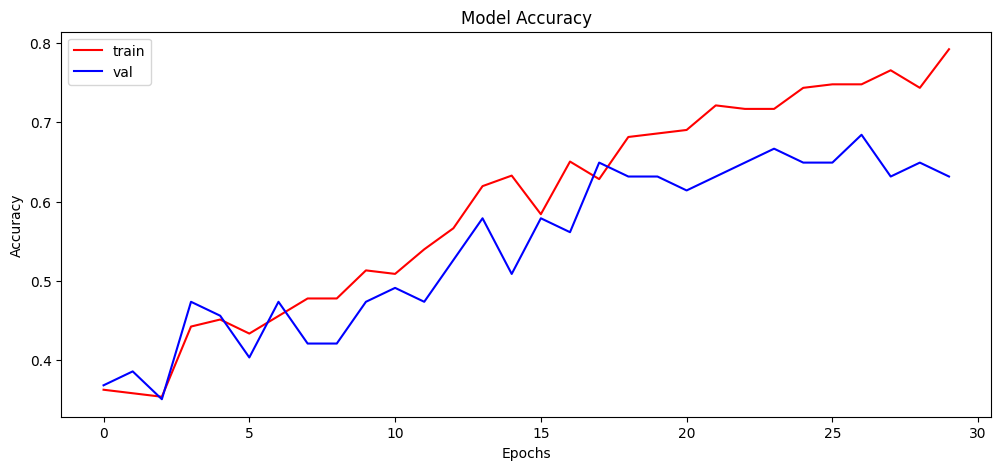

In [16]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()


In [17]:
Y_pred = model.predict(X_test)
score = model.evaluate(X_test, Y_test)
print('Accuracy over the test set: \n ', round((score[1]*100), 2), '%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7500 - loss: 3.5502
Accuracy over the test set: 
  75.0 %


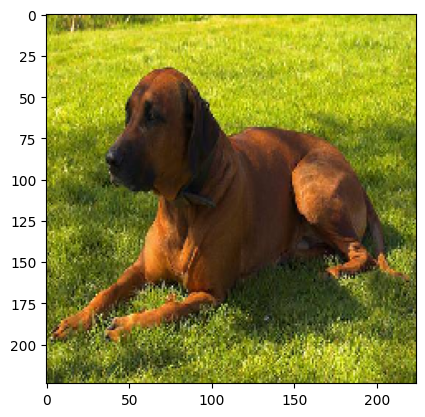

Originally :  rhodesian_ridgeback
Predicted :  rhodesian_ridgeback
16
[0.05063197 0.7756742  0.17369382]


In [18]:
i = np.random.randint(0,32)
plt.imshow(X_test[i,:,:,:])
plt.show()

print("Originally : ",labels['breed'][np.argmax(Y_test[i])])
print("Predicted : ",labels['breed'][np.argmax(Y_pred[i])])
print(i)
print(Y_pred[i])

In [19]:
model.save("dog_breed.h5")